# KLSE Index Movement Classification Using LSTM

This notebook demonstrates building a binary classifier that predicts whether the next trading-day closing price of the Kuala Lumpur Stock Exchange (KLSE) index will move up (1) or stay the same / move down (0).

High-level parts (so you can run and review step-by-step):

1. Setup & Imports
2. Data download
3. Data inspection & saving
4. Exploratory plots
5. Target creation
6. Feature selection & scaling
7. Sequence creation for LSTM
8. Train / Test split
9. Model building & Compile
10. Train The Model
11. Evaluation & visualization
12. Save results

Notes:

This notebook uses yfinance, pandas, scikit-learn and TensorFlow/Keras. Make sure these packages are installed in your environment.

# Step 1 — Setup & Imports

Import required libraries and set any global configuration. If you run this notebook from a different working directory, adjust paths in the save/load cells accordingly.

In [1]:
import os
import pickle

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from pathlib import Path

# Ensure folders are created at the project root
# If notebook is inside a "Notebook" folder, move one level up as project root
current_dir = Path.cwd()

if current_dir.name.lower() in ["notebook", "notebooks"]:
    project_root = current_dir.parent
else:
    project_root = current_dir

# Create output folders if they do not exist
os.makedirs(project_root / "Dataset", exist_ok=True)
os.makedirs(project_root / "Result", exist_ok=True)

print("Setup complete. Libraries imported and folders created.")

Setup complete. Libraries imported and folders created.


# Step 2 — Download KLSE data from Yahoo Finance

Define the KLSE ticker symbol and the date range to download. Modify the ticker or date range if you want data for other assets or periods.

In [2]:
# Define the KLSE ticker
ticker = "^KLSE"

# Download historical data for the KLSE index
df = yf.download(
    ticker,
    start="2005-01-01",
    end="2026-01-01",
    interval="1d"
)

# Some yfinance versions return MultiIndex columns, even for a single ticker.
# Flatten the columns to keep standard names such as Open, High, Low, Close, and Volume.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Sort by date and remove incomplete rows
df = df.sort_index()
df = df.dropna()

print("Data downloaded successfully.")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df.index.min(), "to", df.index.max())

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully.
Dataset shape: (5151, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Date range: 2005-01-03 00:00:00 to 2025-12-31 00:00:00


# Step 3 — Data Inspection & Saving

Inspect the downloaded DataFrame to confirm successful retrieval and to get an initial sense of the data (rows, columns, missing values, basic statistics). Save a clean copy for reproducibility.

In [3]:
# Display first 5 rows
print(df.head())

Price            Close        High         Low        Open     Volume
Date                                                                 
2005-01-03  903.840027  907.020020  897.130005  907.020020          0
2005-01-04  902.489990  904.440002  897.770020  900.679993          0
2005-01-05  907.960022  908.859985  901.700012  901.700012          0
2005-01-06  910.419983  912.080017  907.010010  907.950012          0
2005-01-07  916.280029  918.559998  909.840027  910.900024  102465200


In [4]:
# Display last 5 rows
print(df.tail())

Price             Close         High          Low         Open     Volume
Date                                                                     
2025-12-24  1678.310059  1678.849976  1673.640015  1676.000000  154290900
2025-12-26  1677.099976  1678.290039  1670.829956  1677.500000   95594100
2025-12-29  1680.989990  1680.989990  1668.479980  1677.310059  130192300
2025-12-30  1684.530029  1684.530029  1673.869995  1677.660034  150847100
2025-12-31  1680.109985  1681.780029  1671.589966  1681.780029  196453800


In [5]:
# Check dataset size
print("Dataset shape:", df.shape)

Dataset shape: (5151, 5)


In [6]:
# Check column names
print("Columns:")
print(df.columns)

Columns:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [7]:
# Check dataset information
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.DataFrame'>
DatetimeIndex: 5151 entries, 2005-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5151 non-null   float64
 1   High    5151 non-null   float64
 2   Low     5151 non-null   float64
 3   Open    5151 non-null   float64
 4   Volume  5151 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 241.5 KB
None


In [8]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [9]:
# Show basic statistical summary
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
Price        Close         High          Low         Open        Volume
count  5151.000000  5151.000000  5151.000000  5151.000000  5.151000e+03
mean   1484.730648  1489.958812  1478.726264  1484.606838  1.536661e+08
std     272.130661   272.484490   271.857629   272.239904  8.690526e+07
min     829.409973   837.690002   801.270020   830.440002  0.000000e+00
25%    1364.169983  1369.489990  1357.699951  1363.635010  1.014004e+08
50%    1557.150024  1562.890015  1550.900024  1557.030029  1.329108e+08
75%    1668.265015  1673.179993  1662.334961  1668.195007  1.809062e+08
max    1895.180054  1896.229980  1891.660034  1895.550049  9.730662e+08


In [10]:
# Save the raw downloaded dataset with Date preserved as a column
# Convert index min and max date into safe filename format
date_from = pd.to_datetime(df.index.min()).strftime("%Y-%m-%d")
date_to = pd.to_datetime(df.index.max()).strftime("%Y-%m-%d")
dataset_path=str(project_root / "Dataset" / f"KLSE_from_{date_from}_to_{date_to}_data.csv")
df.to_csv(dataset_path, index=True, index_label="Date")
print("Dataset saved successfully as {}".format(dataset_path))

Dataset saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Dataset\KLSE_from_2005-01-03_to_2025-12-31_data.csv


# Step 4 — Exploratory Plots

Plot the Close price over time to visualize the long-term movement of the KLSE index. Use additional plots here for further EDA if desired.

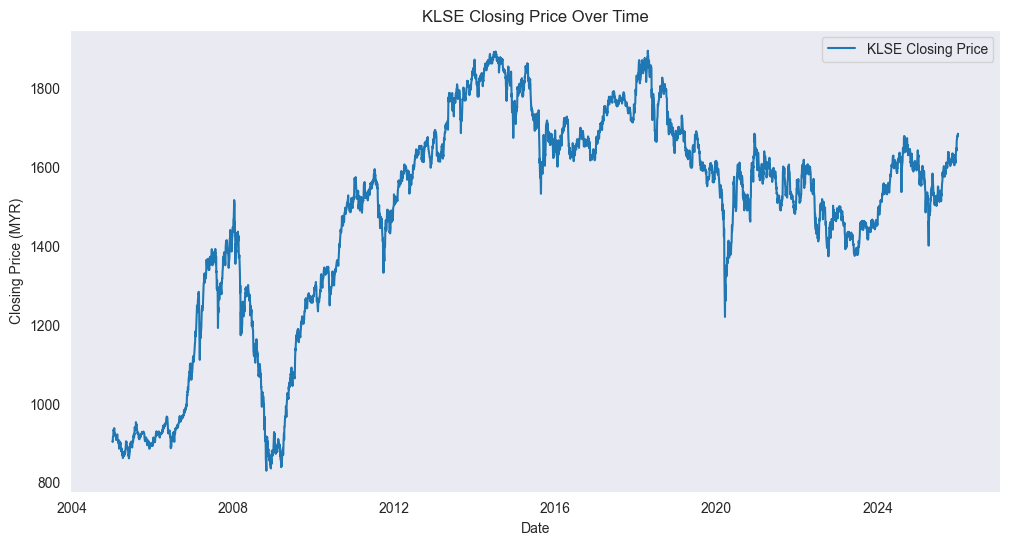

In [11]:
# Plot the closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='KLSE Closing Price')
plt.title('KLSE Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (MYR)')
plt.legend()
plt.grid()
plt.show()

# Step 5 — Target Creation

Create the binary target variable. The target is 1 when the next trading day's Close is greater than the current day's Close, otherwise 0. Drop the last row which has no next-day label.

In [12]:
# Create target variable
# 1 = Next trading day closing price is higher than current day closing price
# 0 = Next trading day closing price is lower than or equal to current day closing price

# Create next-day closing price first
df["Next_Close"] = df["Close"].shift(-1)

# Create binary target variable
df["Target"] = (df["Next_Close"] > df["Close"]).astype(int)

# Remove the last row because it has no next trading day closing price
df = df.dropna(subset=["Next_Close"])

# Remove helper column after target creation
df = df.drop(columns=["Next_Close"])

# Check target result
print(df[["Close", "Target"]].head())
print(df[["Close", "Target"]].tail())

# Check class distribution
print(df["Target"].value_counts())

Price            Close  Target
Date                          
2005-01-03  903.840027       0
2005-01-04  902.489990       1
2005-01-05  907.960022       1
2005-01-06  910.419983       1
2005-01-07  916.280029       1
Price             Close  Target
Date                           
2025-12-23  1676.640015       1
2025-12-24  1678.310059       0
2025-12-26  1677.099976       1
2025-12-29  1680.989990       1
2025-12-30  1684.530029       0
Target
1    2677
0    2473
Name: count, dtype: int64


# Step 6 — Feature Selection & Scaling

Select input features for the model. Here we use common OHLCV features: Open, High, Low, Close and Volume. Then normalize the features to [0,1] with MinMaxScaler.

In [13]:
# Select input features for LSTM model
features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["Target"]

# Display selected features
print(X.head())
print(y.head())

# Check feature shape
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Price             Open        High         Low       Close     Volume
Date                                                                 
2005-01-03  907.020020  907.020020  897.130005  903.840027          0
2005-01-04  900.679993  904.440002  897.770020  902.489990          0
2005-01-05  901.700012  908.859985  901.700012  907.960022          0
2005-01-06  907.950012  912.080017  907.010010  910.419983          0
2005-01-07  910.900024  918.559998  909.840027  916.280029  102465200
Date
2005-01-03    0
2005-01-04    1
2005-01-05    1
2005-01-06    1
2005-01-07    1
Name: Target, dtype: int64
Feature shape: (5150, 5)
Target shape: (5150,)


## Save UI Support Files

These files are required by the future UI application. The UI will use the same feature order and the latest 59 trading days to build a 60-day LSTM input sequence together with the user input.

In [14]:
# Save the feature order for the UI application
features_path = project_root / "Result" / "KLSE_features.pkl"

with open(features_path, "wb") as file:
    pickle.dump(features, file)

print(f"Feature list saved successfully as {features_path}")

# Save the latest 29 trading days for UI prediction
# UI logic: latest 29 historical trading days + 1 user input day = 30-day LSTM input sequence
latest_29_days = df[features].tail(29)
latest_29_days.to_csv(project_root / "Result" / "KLSE_latest_29_days.csv", index=False)

print("Latest 29 trading days saved successfully as {}".format(project_root / "Result" / "KLSE_latest_29_days.csv"))

# Save the latest 59 trading days for UI prediction
# UI logic: latest 59 historical trading days + 1 user input day = 60-day LSTM input sequence
latest_59_days = df[features].tail(59)
latest_59_days.to_csv(project_root / "Result" / "KLSE_latest_59_days.csv", index=False)

print("Latest 59 trading days saved successfully as {}".format(project_root / "Result" / "KLSE_latest_59_days.csv"))

# Save the latest 89 trading days for UI prediction
# UI logic: latest 89 historical trading days + 1 user input day = 90-day LSTM input sequence
latest_89_days = df[features].tail(89)
latest_89_days.to_csv(project_root / "Result" / "KLSE_latest_89_days.csv", index=False)

print("Latest 89 trading days saved successfully as {}".format(project_root / "Result" / "KLSE_latest_89_days.csv"))

Feature list saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_features.pkl
Latest 29 trading days saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_29_days.csv
Latest 59 trading days saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_59_days.csv
Latest 89 trading days saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_89_days.csv


In [15]:
# Normalise the input features into range 0 to 1
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Check scaled data
print(X_scaled[:5])
print("Scaled feature shape:", X_scaled.shape)


[[0.07189869 0.06549589 0.08791348 0.06983688 0.        ]
 [0.06594623 0.06305855 0.08850044 0.06857015 0.        ]
 [0.06690389 0.0672341  0.09210465 0.07370262 0.        ]
 [0.07277183 0.07027606 0.09697447 0.07601077 0.        ]
 [0.07554151 0.07639768 0.09956988 0.08150919 0.10530137]]
Scaled feature shape: (5150, 5)


## Save Trained Scaler

The scaler is saved because the UI application must apply the same feature scaling used during model training.

In [16]:
# Save the trained MinMaxScaler for the UI application
features_path = project_root / "Result" /  "KLSE_scaler.pkl"

with open(features_path, "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully as {}".format(features_path))

Scaler saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_scaler.pkl


# Step 7 — Sequence Creation for LSTM

Create time-series sequences for LSTM input. We use a lookback window of 60 trading days (time_steps = 60). The function below converts the scaled feature matrix and labels into (samples, time_steps, features) and corresponding labels.

In [17]:
# Function to create LSTM sequences
def create_sequences(X, y, time_steps):
    Xs, ys = [], []

    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y.iloc[i])

    return np.array(Xs), np.array(ys)


# Support multiple sequence lengths
time_steps_list = [30, 60, 90]

sequence_data = {}

for time_steps in time_steps_list:
    X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

    sequence_data[time_steps] = {
        "X_seq": X_seq,
        "y_seq": y_seq
    }

    print(f"{time_steps}-day sequence created successfully")
    print("X sequence shape:", X_seq.shape)
    print("y sequence shape:", y_seq.shape)
    print("-" * 50)

30-day sequence created successfully
X sequence shape: (5120, 30, 5)
y sequence shape: (5120,)
--------------------------------------------------
60-day sequence created successfully
X sequence shape: (5090, 60, 5)
y sequence shape: (5090,)
--------------------------------------------------
90-day sequence created successfully
X sequence shape: (5060, 90, 5)
y sequence shape: (5060,)
--------------------------------------------------


# Step 8 — Train / Test Split

Split sequences into training and testing sets. We use an 80/20 split (no random shuffle to preserve time order). This is important for time-series forecasting/classification to avoid look-ahead bias.

In [18]:
# Split data into training and testing sets for 30, 60, and 90 days
# 80% training data, 20% testing data

split_data = {}

for time_steps in time_steps_list:
    X_seq = sequence_data[time_steps]["X_seq"]
    y_seq = sequence_data[time_steps]["y_seq"]

    train_size = int(len(X_seq) * 0.8)

    X_train = X_seq[:train_size]
    X_test = X_seq[train_size:]

    y_train = y_seq[:train_size]
    y_test = y_seq[train_size:]

    split_data[time_steps] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"{time_steps}-day train-test split completed")
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)
    print("-" * 50)

30-day train-test split completed
X_train shape: (4096, 30, 5)
X_test shape: (1024, 30, 5)
y_train shape: (4096,)
y_test shape: (1024,)
--------------------------------------------------
60-day train-test split completed
X_train shape: (4072, 60, 5)
X_test shape: (1018, 60, 5)
y_train shape: (4072,)
y_test shape: (1018,)
--------------------------------------------------
90-day train-test split completed
X_train shape: (4048, 90, 5)
X_test shape: (1012, 90, 5)
y_train shape: (4048,)
y_test shape: (1012,)
--------------------------------------------------


# Step 9 — Model Building

Build an LSTM-based Keras sequential model for binary classification. The architecture below is a simple baseline: two LSTM layers with dropout and a sigmoid output neuron.

In [19]:
# Function to build LSTM model
def build_lstm_model(input_shape):
    model = Sequential()

    # First LSTM layer
    model.add(LSTM(
        units=64,
        return_sequences=True,
        input_shape=input_shape
    ))
    model.add(Dropout(0.2))

    # Second LSTM layer
    model.add(LSTM(
        units=32,
        return_sequences=False
    ))
    model.add(Dropout(0.2))

    # Output layer for binary classification
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Build models for 30, 60, and 90 trading days

models = {}

for time_steps in time_steps_list:
    X_train = split_data[time_steps]["X_train"]

    input_shape = (X_train.shape[1], X_train.shape[2])

    model = build_lstm_model(input_shape)

    models[time_steps] = model

    print(f"{time_steps}-day LSTM model created successfully")
    print(f"Input shape: {input_shape}")
    model.summary()
    print("-" * 50)

30-day LSTM model created successfully
Input shape: (30, 5)


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 90, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

--------------------------------------------------


# Step 10 — Train The Model

Compile the model with Adam optimizer and binary cross-entropy loss. Accuracy is used as a simple performance metric; consider adding AUC for imbalanced datasets. Then train the model.

In [20]:
# Train the LSTM model
histories = {}

for time_steps in time_steps_list:
    model = models[time_steps]

    X_train = split_data[time_steps]["X_train"]
    y_train = split_data[time_steps]["y_train"]

    print(f"Training {time_steps}-day LSTM model...")

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    histories[time_steps] = history

    print(f"{time_steps}-day model training completed")
    print("-" * 50)

Training 30-day LSTM model...
Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5201 - loss: 0.6937 - val_accuracy: 0.4951 - val_loss: 0.6940
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5281 - loss: 0.6913 - val_accuracy: 0.4951 - val_loss: 0.7084
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5305 - loss: 0.6926 - val_accuracy: 0.4951 - val_loss: 0.6956
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5327 - loss: 0.6916 - val_accuracy: 0.4951 - val_loss: 0.6972
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5333 - loss: 0.6908 - val_accuracy: 0.4951 - val_loss: 0.6930
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5366 - loss: 0.6911 - val_accuracy: 0.4951 - val_loss: 0.6936
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5299 - loss: 0.6909 - val_accuracy: 0.4951 - val_loss: 0.6962
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.

# Step 11 — Evaluation & Visualization

Plot training/validation accuracy and loss to inspect training behavior for signs of overfitting or underfitting. After training, make predictions on the test set and calculate evaluation metrics.

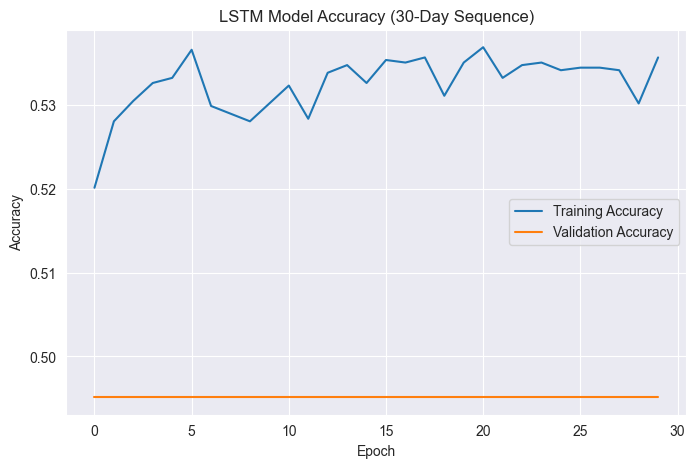

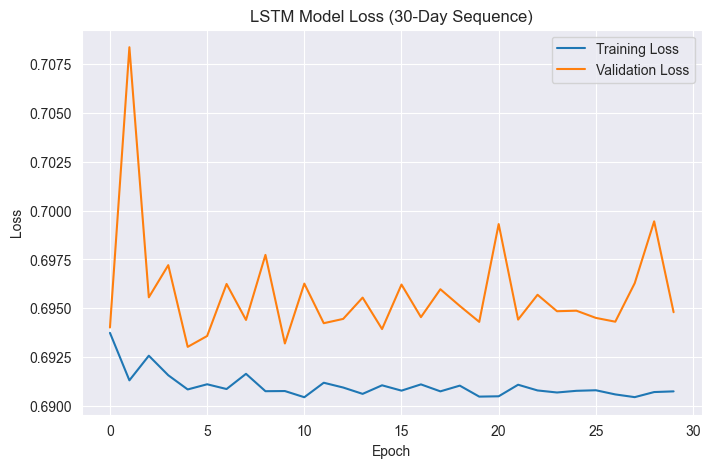

30-day accuracy graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_accuracy_30.png
30-day loss graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_loss_30.png


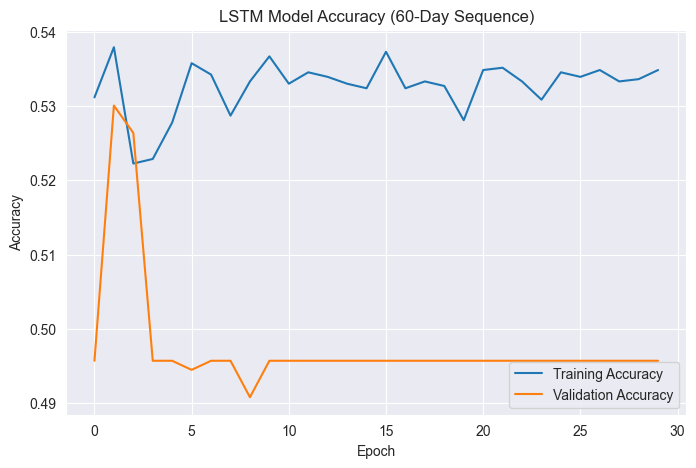

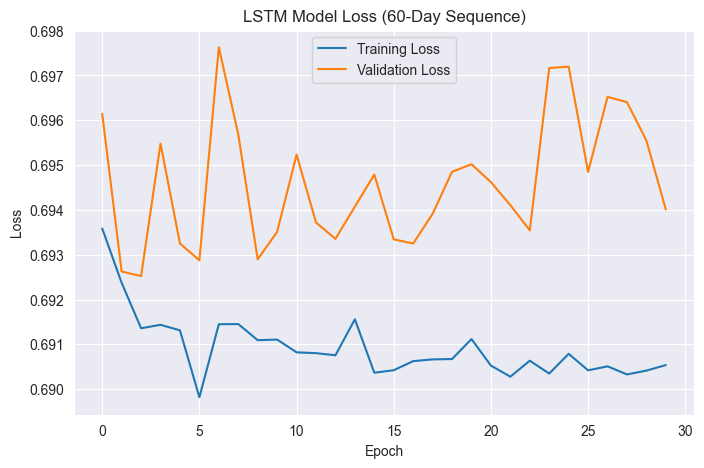

60-day accuracy graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_accuracy_60.png
60-day loss graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_loss_60.png


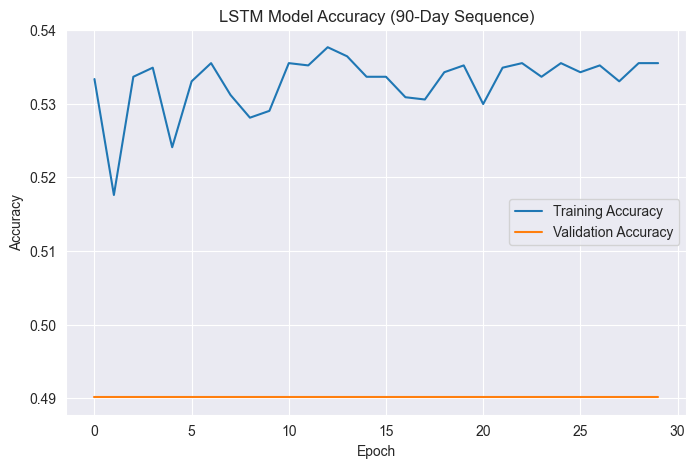

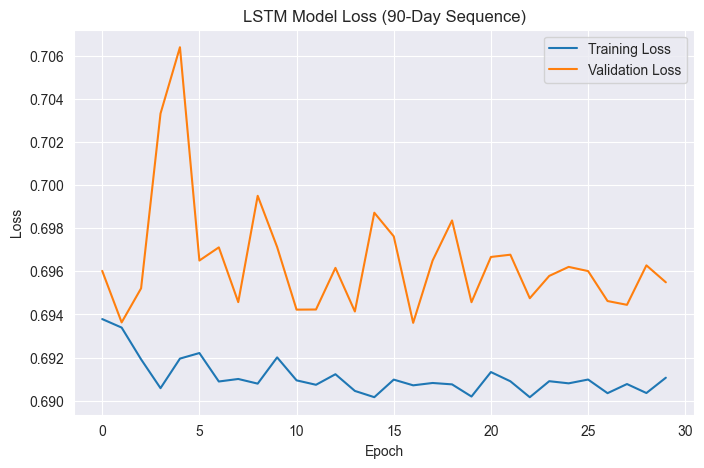

90-day accuracy graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_accuracy_90.png
90-day loss graph saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_loss_90.png


In [21]:
# Save training accuracy and loss graphs for each sequence length

for time_steps in time_steps_list:
    history = histories[time_steps]

    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"LSTM Model Accuracy ({time_steps}-Day Sequence)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    accuracy_path = project_root / "Result" / f"KLSE_LSTM_accuracy_{time_steps}.png"
    plt.savefig(accuracy_path, bbox_inches="tight")
    plt.show()

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"LSTM Model Loss ({time_steps}-Day Sequence)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    loss_path = project_root / "Result" / f"KLSE_LSTM_loss_{time_steps}.png"
    plt.savefig(loss_path, bbox_inches="tight")
    plt.show()

    print(f"{time_steps}-day accuracy graph saved as {accuracy_path}")
    print(f"{time_steps}-day loss graph saved as {loss_path}")

Make predictions on the test set and convert predicted probabilities to class labels using a 0.5 threshold. You can change the threshold to tune precision/recall trade-offs.

In [22]:
# Make predictions for each sequence length
# Convert predicted probabilities to class labels using 0.5 threshold

prediction_results = {}

for time_steps in time_steps_list:
    model = models[time_steps]

    X_test = split_data[time_steps]["X_test"]
    y_test = split_data[time_steps]["y_test"]

    # Make predictions on the test dataset
    y_pred_prob = model.predict(X_test)

    # Convert prediction probabilities into class labels
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Flatten predicted labels for evaluation
    y_pred = y_pred.flatten()

    prediction_results[time_steps] = {
        "y_test": y_test,
        "y_pred_prob": y_pred_prob,
        "y_pred": y_pred
    }

    print(f"{time_steps}-day model prediction completed")
    print("First 10 prediction probabilities:")
    print(y_pred_prob[:10])

    print("\nFirst 10 predicted classes:")
    print(y_pred[:10])

    print("\nFirst 10 actual classes:")
    print(y_test[:10])
    print("-" * 50)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
30-day model prediction completed
First 10 prediction probabilities:
[[0.5282398 ]
 [0.5284125 ]
 [0.52855   ]
 [0.5287358 ]
 [0.52893937]
 [0.5292366 ]
 [0.52955556]
 [0.52987456]
 [0.53017807]
 [0.5304478 ]]

First 10 predicted classes:
[1 1 1 1 1 1 1 1 1 1]

First 10 actual classes:
[0 0 0 0 1 0 1 1 0 0]
--------------------------------------------------
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
60-day model prediction completed
First 10 prediction probabilities:
[[0.52448785]
 [0.52493453]
 [0.52539366]
 [0.5258195 ]
 [0.5261911 ]
 [0.5265741 ]
 [0.52692366]
 [0.52701813]
 [0.5271197 ]
 [0.52720875]]

First 10 predicted classes:
[1 1 1 1 1 1 1 1 1 1]

First 10 actual classes:
[1 1 0 0 0 1 0 1 1 0]
--------------------------------------------------
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
90-day model prediction completed
First 10 prediction probabilities:
[[0.53050625]
 [0.5305986 ]
 [0.5306746 ]
 [0.5307406 ]
 [0.53077435]
 [0.5307943 ]
 [0.5307

Prepare predictions and evaluate model performance using accuracy, precision, recall and F1. The notebook uses zero_division=0 in metrics to avoid exceptions for empty predicted classes.

In [23]:
# Evaluate models for 30, 60, and 90 days

evaluation_results = {}
confusion_matrices = {}

for time_steps in time_steps_list:
    y_test = prediction_results[time_steps]["y_test"]
    y_pred = prediction_results[time_steps]["y_pred"]

    # Ensure predicted labels are flattened
    y_pred = y_pred.flatten()

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    evaluation_results[time_steps] = {
        "Sequence_Days": time_steps,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1
    }

    confusion_matrices[time_steps] = cm

    # Print results
    print(f"{time_steps}-Day Model Evaluation Results")
    print("-" * 40)
    print("y_test shape:", y_test.shape)
    print("y_pred shape:", y_pred.shape)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(cm)
    print("=" * 60)

30-Day Model Evaluation Results
----------------------------------------
y_test shape: (1024,)
y_pred shape: (1024,)
Accuracy: 0.4912109375
Precision: 0.4912109375
Recall: 1.0
F1-score: 0.6588081204977079

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       521
           1       0.49      1.00      0.66       503

    accuracy                           0.49      1024
   macro avg       0.25      0.50      0.33      1024
weighted avg       0.24      0.49      0.32      1024


Confusion Matrix:
[[  0 521]
 [  0 503]]
60-Day Model Evaluation Results
----------------------------------------
y_test shape: (1018,)
y_pred shape: (1018,)
Accuracy: 0.4931237721021611
Precision: 0.4931237721021611
Recall: 1.0
F1-score: 0.6605263157894737

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       516
           1       0.49      1.00      0.66       50

In [24]:
# Convert evaluation results to DataFrame
evaluation_df = pd.DataFrame(evaluation_results.values())

# Display comparison table
print("LSTM Model Evaluation Comparison")
print(evaluation_df)

# Save evaluation comparison result
evaluation_path = project_root / "Result" / "KLSE_LSTM_sequence_comparison.csv"
evaluation_df.to_csv(evaluation_path, index=False)

print(f"Evaluation comparison saved successfully as {evaluation_path}")

LSTM Model Evaluation Comparison
   Sequence_Days  Accuracy  Precision  Recall  F1_score
0             30  0.491211   0.491211     1.0  0.658808
1             60  0.493124   0.493124     1.0  0.660526
2             90  0.493083   0.493083     1.0  0.660490
Evaluation comparison saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_sequence_comparison.csv


Visualize the confusion matrix and compare actual vs predicted movements for a subset of test samples.

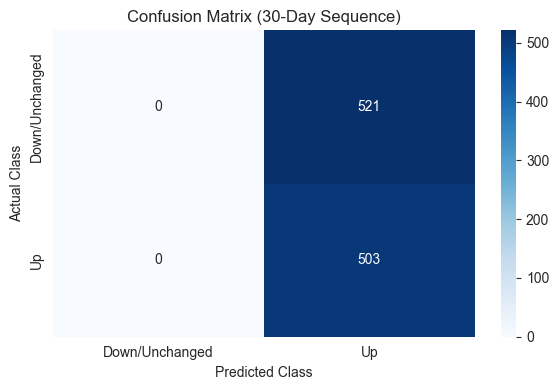

30-day confusion matrix plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_confusion_matrix_30.png


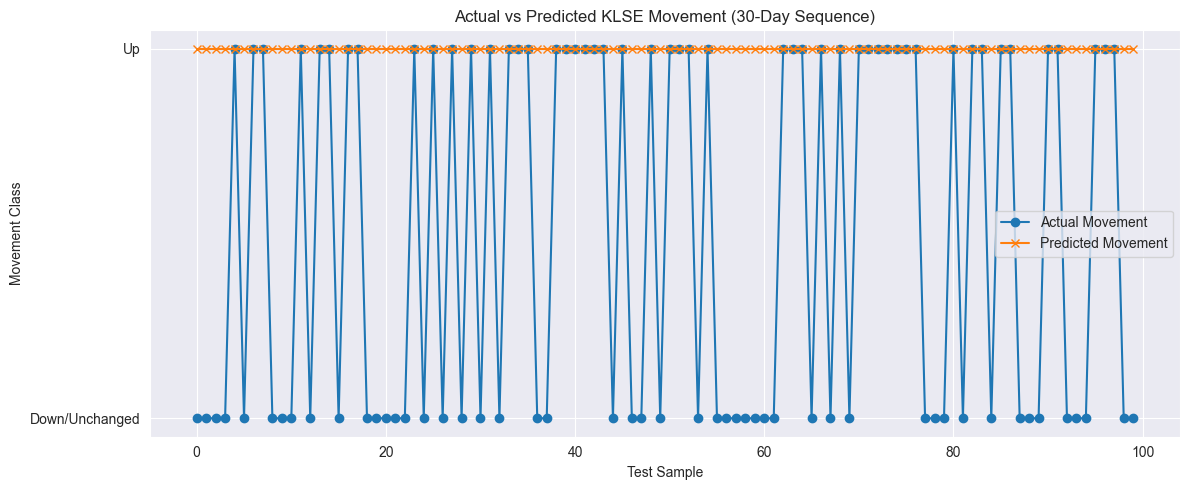

30-day actual vs predicted plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_actual_vs_predicted_30.png
------------------------------------------------------------


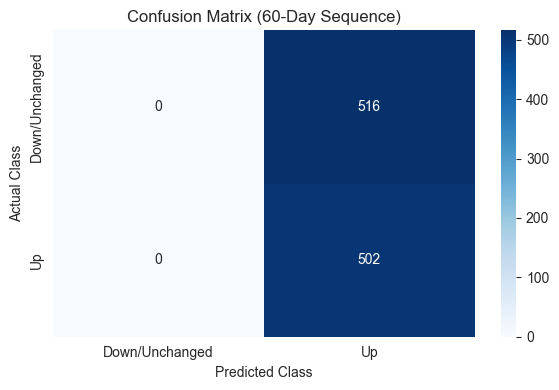

60-day confusion matrix plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_confusion_matrix_60.png


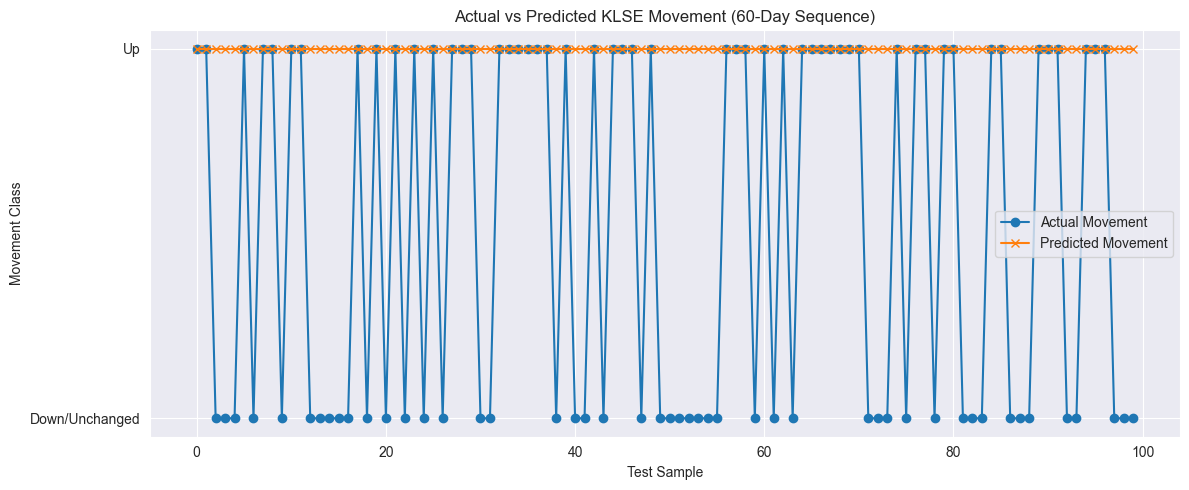

60-day actual vs predicted plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_actual_vs_predicted_60.png
------------------------------------------------------------


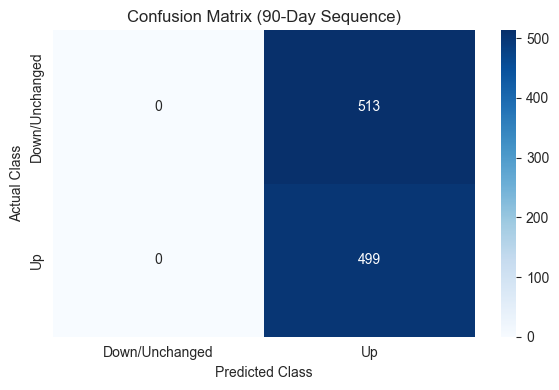

90-day confusion matrix plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_confusion_matrix_90.png


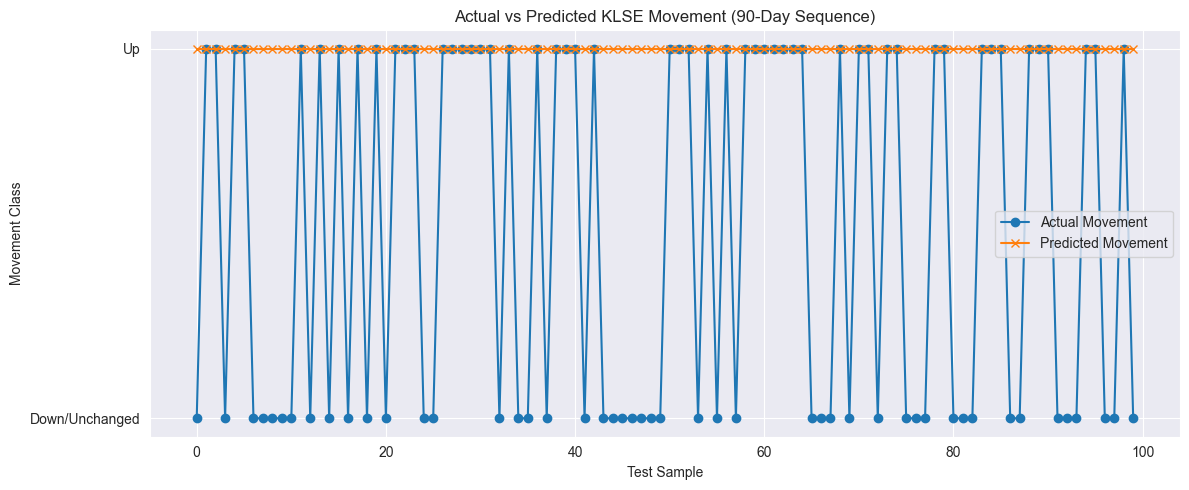

90-day actual vs predicted plot saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_actual_vs_predicted_90.png
------------------------------------------------------------


In [25]:
# Visualize confusion matrix and compare actual vs predicted movements
# for 30-day, 60-day, and 90-day LSTM models

sample_size = 100

for time_steps in time_steps_list:
    y_test = prediction_results[time_steps]["y_test"]
    y_pred = prediction_results[time_steps]["y_pred"]
    cm = confusion_matrices[time_steps]

    # -----------------------------
    # Confusion Matrix Heatmap
    # -----------------------------
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Down/Unchanged", "Up"],
        yticklabels=["Down/Unchanged", "Up"]
    )

    plt.title(f"Confusion Matrix ({time_steps}-Day Sequence)")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()

    cm_plot_path = project_root / "Result" / f"KLSE_LSTM_confusion_matrix_{time_steps}.png"
    plt.savefig(cm_plot_path, bbox_inches="tight")
    plt.show()

    print(f"{time_steps}-day confusion matrix plot saved as {cm_plot_path}")

    # -----------------------------
    # Actual vs Predicted Movement
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(y_test[:sample_size], label="Actual Movement", marker="o")
    plt.plot(y_pred[:sample_size], label="Predicted Movement", marker="x")

    plt.title(f"Actual vs Predicted KLSE Movement ({time_steps}-Day Sequence)")
    plt.xlabel("Test Sample")
    plt.ylabel("Movement Class")
    plt.yticks([0, 1], ["Down/Unchanged", "Up"])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    actual_pred_plot_path = project_root / "Result" / f"KLSE_LSTM_actual_vs_predicted_{time_steps}.png"
    plt.savefig(actual_pred_plot_path, bbox_inches="tight")
    plt.show()

    print(f"{time_steps}-day actual vs predicted plot saved as {actual_pred_plot_path}")
    print("-" * 60)


In [26]:
# Save actual vs predicted results for each sequence length

for time_steps in time_steps_list:
    y_test = prediction_results[time_steps]["y_test"]
    y_pred = prediction_results[time_steps]["y_pred"]
    y_pred_prob = prediction_results[time_steps]["y_pred_prob"].flatten()

    prediction_df = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred,
        "Upward_Probability": y_pred_prob
    })

    prediction_csv_path = project_root / "Result" / f"KLSE_LSTM_prediction_results_{time_steps}.csv"
    prediction_df.to_csv(prediction_csv_path, index=False)

    print(f"{time_steps}-day prediction results saved as {prediction_csv_path}")

30-day prediction results saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_prediction_results_30.csv
60-day prediction results saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_prediction_results_60.csv
90-day prediction results saved as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_prediction_results_90.csv


# Step 12 — Save Results

Save the trained model and evaluation results (evaluation metrics, prediction results, confusion matrix) to the project's Result folder so outputs can be reviewed and reused. Also includes suggestions for next steps.

In [27]:
# Save trained models and evaluation outputs to the Result folder
# This includes model files, evaluation metrics, prediction results, and confusion matrices

# Save overall evaluation comparison table
evaluation_df = pd.DataFrame(evaluation_results.values())

evaluation_comparison_path = project_root / "Result" / "KLSE_LSTM_sequence_comparison.csv"
evaluation_df.to_csv(evaluation_comparison_path, index=False)

print(f"Evaluation comparison saved successfully as {evaluation_comparison_path}")

# Save outputs for each sequence length
for time_steps in time_steps_list:
    model = models[time_steps]

    y_test = prediction_results[time_steps]["y_test"]
    y_pred = prediction_results[time_steps]["y_pred"]
    y_pred_prob = prediction_results[time_steps]["y_pred_prob"].flatten()
    cm = confusion_matrices[time_steps]

    # -----------------------------
    # Save trained model
    # -----------------------------
    model_h5_path = project_root / "Result" / f"KLSE_LSTM_model_{time_steps}.h5"
    model_keras_path = project_root / "Result" / f"KLSE_LSTM_model_{time_steps}.keras"

    model.save(model_h5_path)
    model.save(model_keras_path)

    # -----------------------------
    # Save evaluation metrics
    # -----------------------------
    metrics_df = pd.DataFrame([evaluation_results[time_steps]])

    metrics_path = project_root / "Result" / f"KLSE_LSTM_evaluation_results_{time_steps}.csv"
    metrics_df.to_csv(metrics_path, index=False)

    # -----------------------------
    # Save prediction results
    # -----------------------------
    prediction_df = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred,
        "Upward_Probability": y_pred_prob
    })

    prediction_path = project_root / "Result" / f"KLSE_LSTM_prediction_results_{time_steps}.csv"
    prediction_df.to_csv(prediction_path, index=False)

    # -----------------------------
    # Save confusion matrix
    # -----------------------------
    confusion_matrix_df = pd.DataFrame(
        cm,
        index=["Actual Down/Unchanged", "Actual Up"],
        columns=["Predicted Down/Unchanged", "Predicted Up"]
    )

    confusion_matrix_path = project_root / "Result" / f"KLSE_LSTM_confusion_matrix_{time_steps}.csv"
    confusion_matrix_df.to_csv(confusion_matrix_path)

    print(f"{time_steps}-day model and results saved successfully.")
    print(f"Model H5: {model_h5_path}")
    print(f"Model Keras: {model_keras_path}")
    print(f"Metrics: {metrics_path}")
    print(f"Predictions: {prediction_path}")
    print(f"Confusion Matrix: {confusion_matrix_path}")
    print("-" * 60)

# Save 60-day model as default model for compatibility with UI or earlier code
default_time_steps = 60

default_model_h5_path = project_root / "Result" / "KLSE_LSTM_model.h5"
default_model_keras_path = project_root / "Result" / "KLSE_LSTM_model.keras"

models[default_time_steps].save(default_model_h5_path)
models[default_time_steps].save(default_model_keras_path)

print("Default 60-day model also saved for compatibility.")
print(f"Default H5 model: {default_model_h5_path}")
print(f"Default Keras model: {default_model_keras_path}")


Evaluation comparison saved successfully as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_sequence_comparison.csv
30-day model and results saved successfully.
Model H5: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_model_30.h5
Model Keras: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_model_30.keras
Metrics: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_evaluation_results_30.csv
Predictions: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_prediction_results_30.csv
Confusion Matrix: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_confusion_matrix_30.csv
------------------------------------------------------------
60-day model and results saved successfully.
Model H5: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_model_60.h5
Model Keras: C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_LSTM_mode

In [28]:
# Save latest historical records for UI application
# User input will be added as the final day to form complete sequences

latest_days_config = {
    30: 29,
    60: 59,
    90: 89
}

for time_steps, latest_days in latest_days_config.items():
    latest_data = df[features].tail(latest_days)

    latest_data_path = project_root / "Result" / f"KLSE_latest_{latest_days}_days.csv"
    latest_data.to_csv(latest_data_path, index=False)

    print(f"Latest {latest_days} days saved for {time_steps}-day UI input as {latest_data_path}")

Latest 29 days saved for 30-day UI input as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_29_days.csv
Latest 59 days saved for 60-day UI input as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_59_days.csv
Latest 89 days saved for 90-day UI input as C:\Users\User\PycharmProjects\KLSE_Index_Movement_LSTM\Result\KLSE_latest_89_days.csv
